# Project Universe

Concept nodes (diamonds) sit at the center of themes. Project nodes (circles) orbit them.
Edit `graph_data.yaml` to reshape — add nodes, rewire edges, adjust domains.
Run `seed_graph.py` to surface new projects from MEMORY.md.

In [1]:
import yaml
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

with open('graph_data.yaml') as f:
    data = yaml.safe_load(f)

In [2]:
DOMAIN_COLORS = {
    'research_academic': '#4e9af1',
    'creative_tech':     '#c084fc',
    'pi_infra':          '#22c55e',
    'creative_writing':  '#f472b6',
    'life':              '#fb923c',
    'tools':             '#f59e0b',
    'hardware':          '#84cc16',
    'civic':             '#14b8a6',
    'art':               '#06b6d4',
    'shelved':           '#4b5563',
}

CONCEPT_COLORS = {
    'theory':          '#ff6b6b',
    'tech':            '#38bdf8',
    'research_domain': '#34d399',
    'creative':        '#e879f9',
    'life':            '#fbbf24',
}

G = nx.Graph()

for c in data['concepts']:
    G.add_node(c['id'],
               label=c['label'],
               type='concept',
               group=c['group'],
               color=CONCEPT_COLORS[c['group']])

for p in data['projects']:
    G.add_node(p['id'],
               label=p['label'],
               type='project',
               domain=p['domain'],
               color=DOMAIN_COLORS.get(p['domain'], '#888888'))
    for concept_id in p.get('connects_to', []):
        G.add_edge(p['id'], concept_id)

for u, v in data.get('concept_edges', []):
    G.add_edge(u, v)

print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

44 nodes, 70 edges


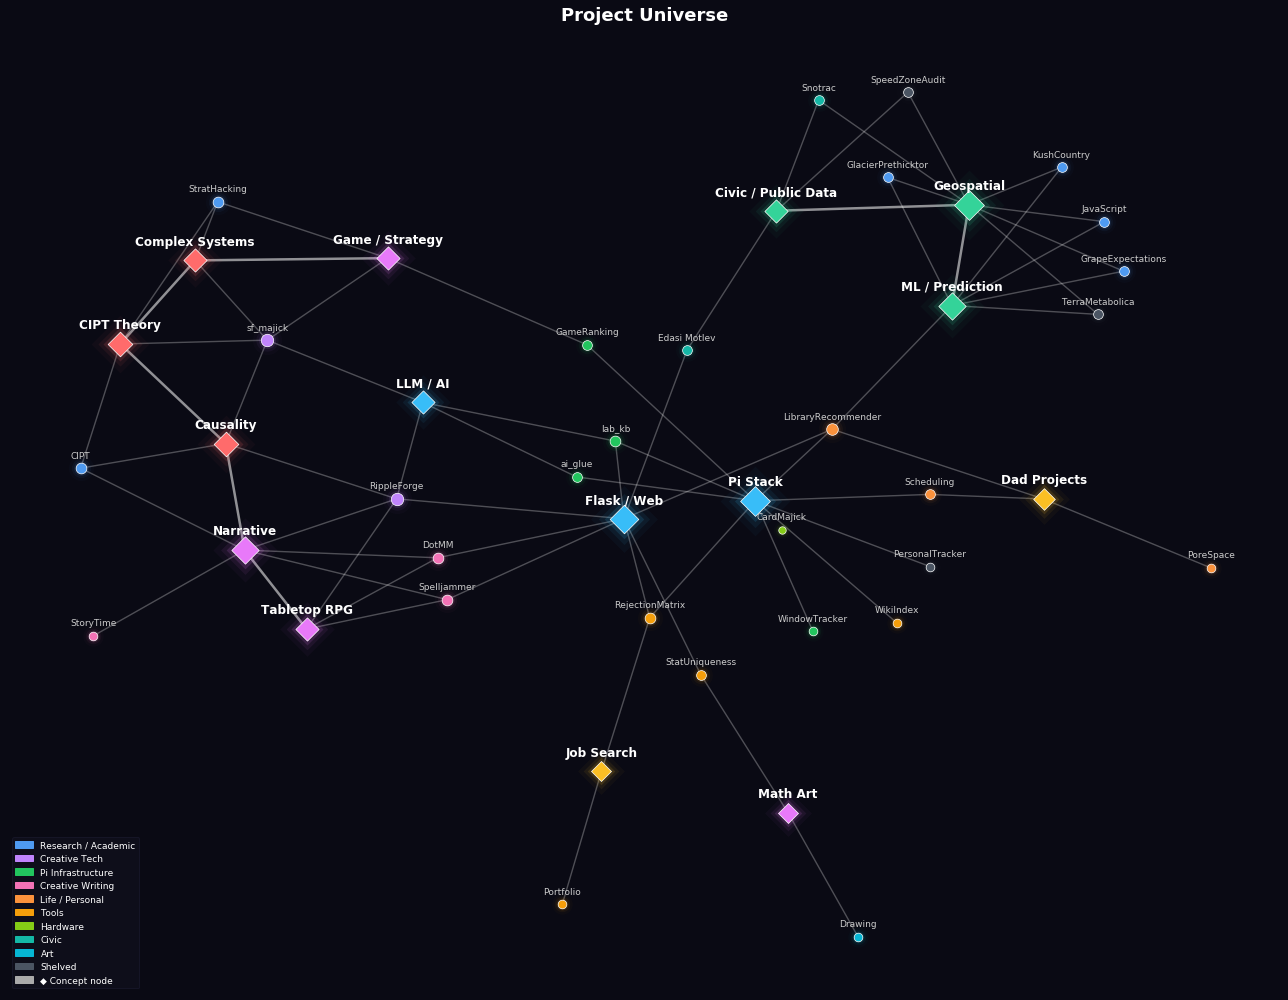

Saved → project_universe.png


In [3]:

# --- Layout ---
pos = nx.kamada_kawai_layout(G, scale=3.5)

# --- Figure ---
BG = '#0a0a14'
fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis('off')

# --- Edges ---
for u, v in G.edges():
    u_type = G.nodes[u]['type']
    v_type = G.nodes[v]['type']
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    if u_type == 'concept' and v_type == 'concept':
        lw, alpha = 2.5, 0.55
    else:
        lw, alpha = 1.4, 0.28
    ax.plot([x0, x1], [y0, y1], color='#ffffff', alpha=alpha, lw=lw, zorder=1)

# --- Project nodes (circles) ---
projects = [n for n in G.nodes() if G.nodes[n]['type'] == 'project']
for node in projects:
    x, y = pos[node]
    color = G.nodes[node]['color']
    size = 55 + G.degree(node) * 20
    for mult, a in [(5.5, 0.025), (3.2, 0.055), (1.9, 0.11)]:
        ax.scatter(x, y, s=size * mult, c=[color], alpha=a,
                   marker='o', zorder=2, linewidths=0)
    ax.scatter(x, y, s=size, c=[color], alpha=1.0,
               marker='o', zorder=3, linewidths=0.7, edgecolors='white')

# --- Concept nodes (diamonds) ---
concepts = [n for n in G.nodes() if G.nodes[n]['type'] == 'concept']
for node in concepts:
    x, y = pos[node]
    color = G.nodes[node]['color']
    size = 130 + G.degree(node) * 35
    for mult, a in [(5.5, 0.035), (3.2, 0.07), (1.9, 0.14)]:
        ax.scatter(x, y, s=size * mult, c=[color], alpha=a,
                   marker='D', zorder=4, linewidths=0)
    ax.scatter(x, y, s=size, c=[color], alpha=1.0,
               marker='D', zorder=5, linewidths=0.7, edgecolors='white')

# --- Labels ---
for node in G.nodes():
    x, y = pos[node]
    label = G.nodes[node]['label']
    ntype = G.nodes[node]['type']
    offset = 0.09 if ntype == 'concept' else 0.06
    fontsize = 12 if ntype == 'concept' else 9
    weight = 'bold' if ntype == 'concept' else 'normal'
    fg = '#ffffff' if ntype == 'concept' else '#cccccc'
    ax.text(x, y + offset, label,
            ha='center', va='bottom',
            fontsize=fontsize, fontweight=weight,
            color=fg, zorder=6)

# --- Legend ---
domain_labels = {
    'research_academic': 'Research / Academic',
    'creative_tech':     'Creative Tech',
    'pi_infra':          'Pi Infrastructure',
    'creative_writing':  'Creative Writing',
    'life':              'Life / Personal',
    'tools':             'Tools',
    'hardware':          'Hardware',
    'civic':             'Civic',
    'art':               'Art',
    'shelved':           'Shelved',
}
patches = [mpatches.Patch(color=DOMAIN_COLORS[k], label=v)
           for k, v in domain_labels.items()]
concept_patch = mpatches.Patch(color='#aaaaaa', label='◆ Concept node')
legend = ax.legend(
    handles=patches + [concept_patch],
    loc='lower left', fontsize=9,
    framealpha=0.25, facecolor='#1a1a2e',
    edgecolor='#333355',
)
for text in legend.get_texts():
    text.set_color('white')

ax.set_title('Project Universe', color='white', fontsize=18,
             fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('project_universe.png', dpi=120, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('Saved → project_universe.png')
